In [13]:
import os
user = 'YS' if os.environ['USER'] in ['yitians', 'sunyitian'] else ''

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
import scipy.integrate as integrate
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from scipy.stats import poisson
import pandas as pd
from astropy.io import fits
from tqdm.notebook import tqdm

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%reload_ext autoreload
%autoreload 2

In [14]:
%matplotlib inline
import matplotlib.pylab as pylab
import warnings
import matplotlib.cbook

from plot_params import params, params_alt
if user == 'YS':
    params = params_alt # '...' is not a valid rc parameter error

warnings.filterwarnings("ignore", category=matplotlib.cbook.mplDeprecation)

pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [15]:
from reproject import reproject_from_healpix, reproject_to_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

In [16]:
# Routine to project to Cartesian
from utils.cart import make_wcs, to_cart

In [17]:
cmap = 'RdBu_r'

In [18]:
! nvidia-smi

Wed Oct 19 12:03:42 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 515.65.01    Driver Version: 515.65.01    CUDA Version: 11.7     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-PCIE...  On   | 00000000:2F:00.0 Off |                    0 |
| N/A   50C    P0   148W / 250W |  30723MiB / 32768MiB |    100%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

## 1. _Fermi_ data

In [19]:
ccube_dir = "/n/holyscratch01/iaifi_lab/yitians/"

In [40]:
# Load and downsamples Fermi counts data

counts_fits = fits.open("{}/ccube_ultracleanveto_bestpsf_joined.fits".format(ccube_dir))

pixel_size_data = 0.1
pixel_size_target = 0.5
extent = 20
i_e = 40

upsample_factor = int(pixel_size_target / pixel_size_data)

counts = counts_fits[0].data[i_e:i_e + 11].sum(0)[int((90 - extent) / pixel_size_data):int((90 + extent) / pixel_size_data),int((90 - extent) / pixel_size_data):int((90 + extent) / pixel_size_data)]
b = counts.shape[0] // upsample_factor
counts_downsampled = counts.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

In [41]:
# Load and downsample exposure

exposure = fits.open("{}/exposure_ultracleanveto_bestpsf_joined.fits".format(ccube_dir))
exposure = exposure[0].data[:, int((90 - extent) / 0.1):int((90 + extent) / 0.1),int((90 - extent) / 0.1):int((90 + extent) / 0.1)]
b = exposure.shape[1] // upsample_factor

In [42]:
# Interpolate exposure to the Zenodo map energy bins

e_min_interp = np.array(counts_fits[1].data[:])['E_MIN'] / 1e3
exposure_interp = interp1d(e_min_interp, exposure, axis=0)
e_bins = np.logspace(np.log10(43.8587), np.log10(714027.0), 38) 
exposure_interp = exposure_interp(e_bins).reshape(len(e_bins), -1, upsample_factor, b, upsample_factor).mean((-1, -3))

## 2. Templates

### 2.1 Pixel area map
Our RoI is $|l|<20^\circ$ and $|b|<20^\circ$ with pixel size of $0.5^\circ$.

In [43]:
theta_edges = np.linspace(70*np.pi/180, 110*np.pi/180, 81)
theta_ints = np.cos(theta_edges[:-1]) - np.cos(theta_edges[1:])
pixel_area_map = np.array([theta_int * np.full((80,), 0.5*np.pi/180) for theta_int in theta_ints])
print(f'{np.max(pixel_area_map):.3e}, {np.min(pixel_area_map):.3e}')

7.615e-05, 7.167e-05


### SkyFACT
RoI is $|l|\le90^\circ$ and $|b|\le20.25^\circ$. \
Pixel size is $0.5^\circ$, image shape is (81, 360).

In [44]:
names = ['ICS', 'pi0ii', 'pi0i', 'pi0o']
names_paper = ['ICS', 'Gas_ring_I', 'Gas_ring_II', 'Gas_ring_III']

<ipython-input-45-743bb821be74>:6: RuntimeWarning: divide by zero encountered in log10
  im = axs[i].imshow(np.flipud(np.log10(image)), cmap='cubehelix',


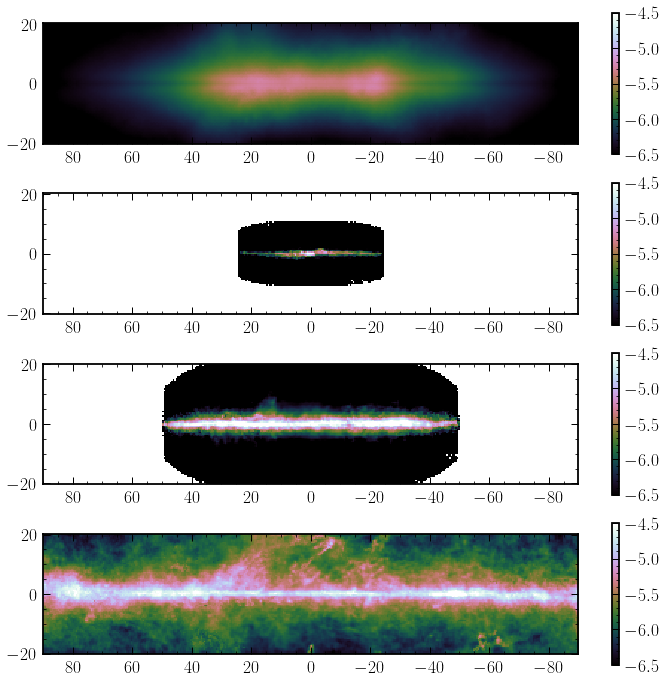

In [45]:
# view templates
fig, axs = plt.subplots(4, 1, figsize=(12,12))

for i, name in enumerate(names):
    image = np.loadtxt(f'../data/external/SkyFACT/r5_map_mean_model_{name}_2_20.dat')
    im = axs[i].imshow(np.flipud(np.log10(image)), cmap='cubehelix',
                       extent=(90,-90,-20.25,20.25), vmin=-6.5, vmax=-4.5)
    # axs[i].set(ylabel=r'$b$ [$^\circ$]')
    # axs[i].set(title=names_paper[i]+'('+name+') $\log_{10}\Phi/$photon cm$^{-1}$s$^{-1}$sr$^{-1}$')
    fig.colorbar(im, ax=axs[i])
# axs[-1].set(xlabel=r'$l$ [$^\circ$]');

[None, None, (1e-09, 0.001)]

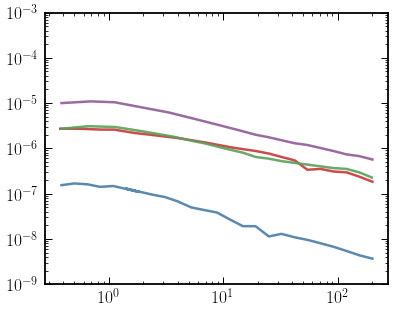

In [46]:
# view ICS and pi spectra
fig, ax = plt.subplots()

for p in names_paper:
    eng, E2dNdE = 10**np.loadtxt(f'../data/external/SkyFACT/{p}_full.csv', unpack=True)
    ax.plot(eng, E2dNdE, label=p)
ax.set(xscale='log', yscale='log', ylim=(1e-9, 1e-3))
# ax.set(xlabel=r'$E$ [GeV]', ylabel=r'$E^2dN/dE$ [GeV cm$^{-2}$s$^{-1}$sr$^{-1}$]')
# ax.set(title='SkyFACT Run5 Full ROI spectra')
# ax.legend();

In [47]:
def downsample(arr, f):
    """ Converts a shape (h, w) array into a (h//f, w//f) array
        by adding the values in f*f blocks.
    """
    h, w = arr.shape
    if h%f != 0 or w%f != 0:
        raise ValueError('h and w need to be multiples of f')
    return np.sum([[arr[i::f, j::f] for j in range(f)] for i in range(f)], axis=(0,1))

In [48]:
temps_SkyFACT = []

eng_bin_start, eng_bin_end = 10, 20 # 2-20 GeV
eng_bin_edge = np.array(counts_fits[1].data[eng_bin_start:eng_bin_end+1])['E_MIN'] / 1e3
print(f'{eng_bin_edge[0]:.3f}-{eng_bin_edge[-1]:.3f} GeV')

for i in range(4):
    # calculate N (summed in spatial direction) for each exposure bin
    eng, E2dNdE = 10**np.loadtxt(f'../data/external/SkyFACT/{names_paper[i]}_full.csv', unpack=True) # [GeV], [photon GeV cm^-2 s^-1 sr^-1]
    dNdE_interp = interp1d(eng, E2dNdE/eng**2) # [photon GeV^-1 cm^-2 s^-1 sr^-1]
    dNdE_func = lambda e: dNdE_interp(e).item()
    Ns = [integrate.quad(dNdE_func, eng_bin_edge[i], eng_bin_edge[i+1])[0] for i in range(10)] # [photon cm^-2 s^-1 sr^-1]
    Ns = Ns/np.sum(Ns) # [1] normalized
    # make exposure map
    exposure_weighted = np.einsum('i,ijk->jk', Ns, exposure[eng_bin_start:eng_bin_end]) # [cm^2 s^1], pixel=0.1 deg
    exposure_weighted = downsample(exposure_weighted, upsample_factor) # [cm^2 s^1], pixel=0.5 deg
    # make counts map
    phi = np.loadtxt(f'../data/external/SkyFACT/r5_map_mean_model_{names[i]}_2_20.dat') # [photon cm^-2 s^-1 sr^-1]
    phi = phi[:, int(phi.shape[1] * 70/180):int(phi.shape[1] * 110/180)]
    phi = (phi[:-1] + phi[1:])/2 # interpolate to -20 < b < 20
    phi *= exposure_weighted # [photon sr^-1]
    phi *= pixel_area_map # [photon]
    temps_SkyFACT.append(phi)
temps_SkyFACT = np.array(temps_SkyFACT)
temp_SkyFACT_ICS, temp_SkyFACT_pi0 = temps_SkyFACT[0], np.sum(temps_SkyFACT[1:], axis=0)

2.000-20.000 GeV


In [49]:
# # save maps
# np.save('../data/external/SkyFACT/template_SkyFACT_ICS.npy',          temp_SkyFACT_ICS)
# np.save('../data/external/SkyFACT/template_SkyFACT_Gas_ring_I.npy',   temps_SkyFACT[1])
# np.save('../data/external/SkyFACT/template_SkyFACT_Gas_ring_II.npy',  temps_SkyFACT[2])
# np.save('../data/external/SkyFACT/template_SkyFACT_Gas_ring_III.npy', temps_SkyFACT[3])
# np.save('../data/external/SkyFACT/template_SkyFACT_pi0.npy',          temp_SkyFACT_pi0)

<ipython-input-51-44be99c10d12>:6: RuntimeWarning: divide by zero encountered in log10
  im = axs[i].imshow(np.flipud(np.log10(temps_SkyFACT[i])), cmap='cubehelix',


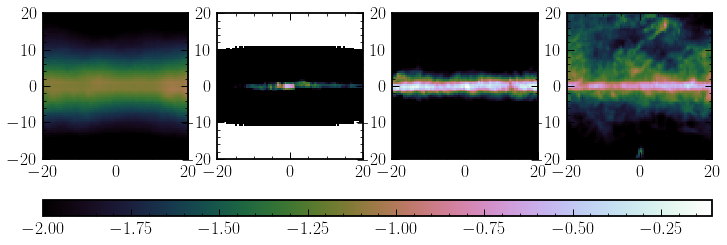

In [51]:
# view counts maps
fig, axs = plt.subplots(1, 4, figsize=(12,5))

vmin, vmax = -2, np.log10(np.max(temps_SkyFACT))
for i in range(4):
    im = axs[i].imshow(np.flipud(np.log10(temps_SkyFACT[i])), cmap='cubehelix',
                       extent=(-20,20,-20,20), vmin=vmin, vmax=vmax)
    #axs[i].set(xlabel=r'$l$ [$^\circ$]', ylabel=r'$b$ [$^\circ$]')
    # axs[i].set(title=names_paper[i]+' $\log_{10}$ counts')
fig.colorbar(im, ax=axs, orientation='horizontal', aspect=40);

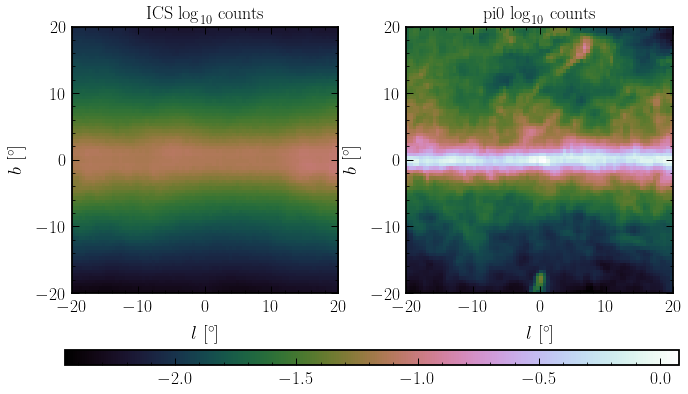

In [21]:
# view counts maps
fig, axs = plt.subplots(1, 2, figsize=(11,7))

vmin = np.log10(np.min([temp_SkyFACT_ICS, temp_SkyFACT_pi0]))
vmax = np.log10(np.max([temp_SkyFACT_ICS, temp_SkyFACT_pi0]))

im = axs[0].imshow(np.flipud(np.log10(temp_SkyFACT_ICS)), cmap='cubehelix',
                   extent=(-20,20,-20,20), vmin=vmin, vmax=vmax)
axs[0].set(xlabel=r'$l$ [$^\circ$]', ylabel=r'$b$ [$^\circ$]')
axs[0].set(title='ICS $\log_{10}$ counts')

im = axs[1].imshow(np.flipud(np.log10(temp_SkyFACT_pi0)), cmap='cubehelix',
                   extent=(-20,20,-20,20), vmin=vmin, vmax=vmax)
axs[1].set(xlabel=r'$l$ [$^\circ$]', ylabel=r'$b$ [$^\circ$]')
axs[1].set(title='pi0 $\log_{10}$ counts')

fig.colorbar(im, ax=axs, orientation='horizontal', aspect=40);